In [2]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from DataManagement import DataHandler, DefaultDataHandler, ImprovedDataHandler,DataViewer
from ModelPipelines import DefaultPipeline, XGBoostSurvivalPipeline
from sksurv.util import Surv
from config import PARAMS_RSF, PARAMS_XGB
from sksurv.metrics import concordance_index_ipcw,concordance_index_censored
import logging
import os
import numpy as np
from LearningCurve import learning_curve_analysis, RiskScorePlotter
from GridSearch import ModelSelection

In [3]:
# Load data
df = pd.read_csv("./X_train/clinical_train.csv", index_col=0)
maf_df = pd.read_csv("./X_train/molecular_train.csv", index_col=0)
target_df = pd.read_csv("./target_train.csv", index_col=0)

In [4]:
# first let's plot some graphs
dtm = DataViewer(df, target_df)
dtm.plot_correlation_matrix()
dtm.plot_float_distributions()

TypeError: numpy string dtypes are not allowed, use 'str' or 'object' instead

In [6]:
# pipeline

    # Build and fit pipeline
data_handler = ImprovedDataHandler(df, maf_df, target_df)
prepared_data = data_handler.prepare()
pipeline_builder = DefaultPipeline(prepared_data)
pipeline = pipeline_builder.build_pipeline()

train_cols = prepared_data[0].columns.tolist()

    # transform the target data
y_surv = Surv.from_dataframe(
    event='OS_STATUS',   # 1 = event, 0 = censored
    time='OS_YEARS',
    data=prepared_data[1]
)

In [7]:
# gridsearch
# first, we will train our model on a random survival forest

grid_search = ModelSelection(model=pipeline, param_grid=PARAMS_RSF, cv=5)
grid_search.fit(prepared_data[0], y_surv)
print("Best Parameters:", grid_search.best_params())    
print("Best Score:", grid_search.best_score())


2026-03-18 11:19:20,032 - INFO - Initialized ModelSelection with model: Pipeline, cv: 5, n_jobs: -1
2026-03-18 11:19:20,033 - INFO - Starting Grid Search with 4 combinations


Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=   9.3s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=  10.0s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=  10.4s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=  10.7s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=100; total time=  10.8s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  17.8s
[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=10, model__n_estimators=200; total time=  

/Users/a33619/Leukemia-Survival-Rate/.venv-2/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END model__max_features=sqrt, model__min_samples_leaf=5, model__min_samples_split=20, model__n_estimators=200; total time=  17.1s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  11.5s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  11.2s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=  11.6s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=100; total time=   5.8s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=10, model__n_estimators=200; total time=   9.7s
[CV] END model__max_features=sqrt, model__min_samples_leaf=10, model__min_samples_split=20, model__n_estimators=100; total time=   4.7s
[CV] END model__max_features=sqrt, model__min_sam

2026-03-18 11:21:03,902 - INFO - Start looping ...
2026-03-18 11:21:03,903 - INFO - Iteration : 0.1
2026-03-18 11:21:09,551 - INFO - Iteration : 0.26
2026-03-18 11:21:21,369 - INFO - Iteration : 0.42000000000000004
2026-03-18 11:21:46,750 - INFO - Iteration : 0.58
2026-03-18 11:22:35,386 - INFO - Iteration : 0.74
2026-03-18 11:23:50,016 - INFO - Iteration : 0.9
/Users/a33619/Leukemia-Survival-Rate/LearningCurve.py:107: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.lineplot(


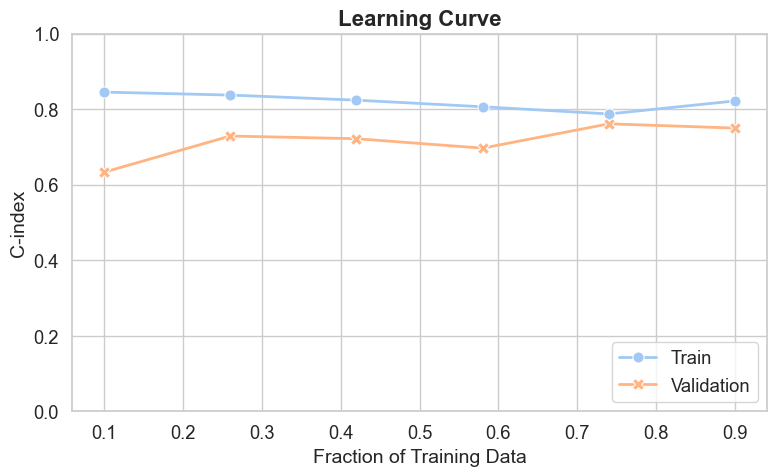

In [8]:
# now, let's plot the learning curve to make sure we don't overfit

learning_curve_analysis(pipeline, prepared_data[0], y_surv, PARAMS_RSF)

In [ ]:
# we don't seem to overfit, no problems of overfitting

Loading Scores...
Done.


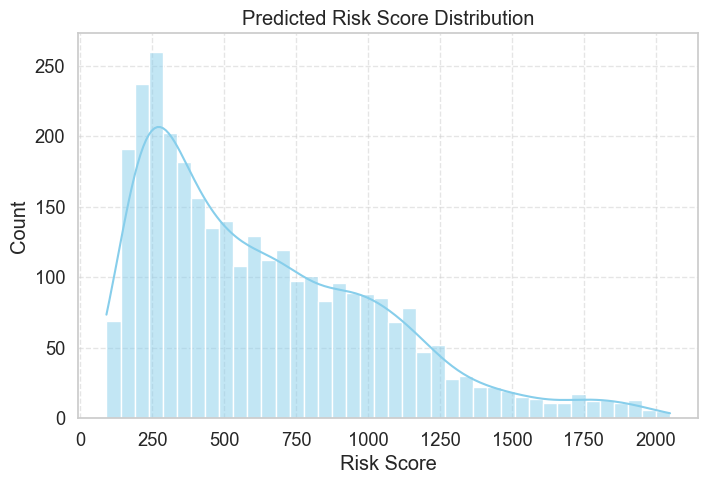

In [ ]:
# plot a few graphs on the risk score / predicted survival...

# first the predicted risk score distribution
best_model=grid_search.best_model
print("Loading Scores...")    
plotter = RiskScorePlotter(model=best_model, X=prepared_data[0], y=y_surv)
print("Done.")
plotter.plot_overall_distribution()

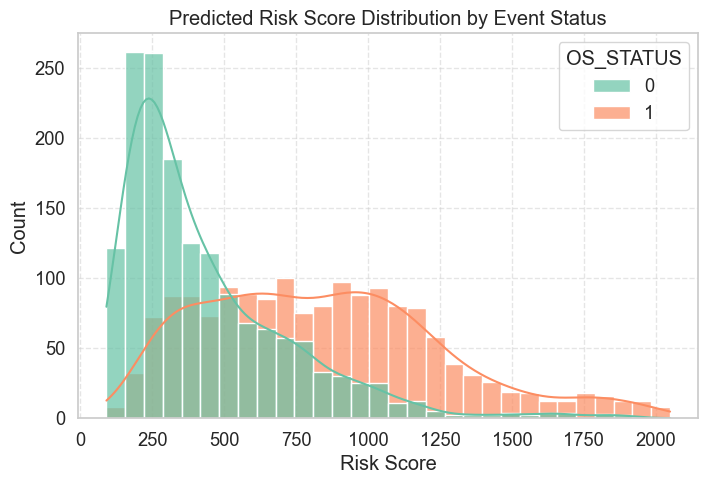

In [ ]:
# first distribution of survival prediction per event (0 or 1)
plotter.plot_by_event_status()

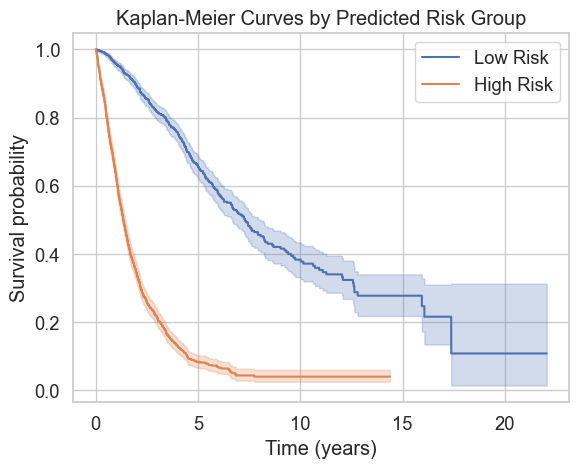

In [11]:
# plot kaplan meyer curve
plotter.plot_kaplan_meier()

In [12]:

# now, we will test trainig our model on a xgboost

# pipeline

    # Build and fit pipeline
data_handler = ImprovedDataHandler(df, maf_df, target_df)
prepared_data = data_handler.prepare()
pipeline_builder = XGBoostSurvivalPipeline(prepared_data)
pipeline = pipeline_builder.build_pipeline()

train_cols = prepared_data[0].columns.tolist()

    # transform the target data
y_surv = Surv.from_dataframe(
    event='OS_STATUS',   # 1 = event, 0 = censored
    time='OS_YEARS',
    data=prepared_data[1]
)

# gridsearch
grid_search = ModelSelection(model=pipeline, param_grid=PARAMS_XGB, cv=5)
grid_search.fit(prepared_data[0], y_surv)
print("Best Parameters:", grid_search.best_params())    
print("Best Score:", grid_search.best_score())


2026-03-18 11:25:44,102 - INFO - Initialized ModelSelection with model: Pipeline, cv: 5, n_jobs: -1
2026-03-18 11:25:44,102 - INFO - Starting Grid Search with 6 combinations


Fitting 5 folds for each of 32 candidates, totalling 160 fits
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=0.8; total time=   1.3s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=0.8; total time=   1.3s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=0.8; total time=   1.3s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=1.0; total time=   1.2s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, model__max_depth=3, model__n_estimators=500, model__reg_lambda=0.5, model__subsample=1.0; total time=   1.2s
[CV] END model__colsample_bytree=0.7, model__learning_rate=0.01, mod

2026-03-18 11:27:23,512 - INFO - Start looping ...
2026-03-18 11:27:23,514 - INFO - Iteration : 0.1
2026-03-18 11:27:37,628 - INFO - Iteration : 0.26
2026-03-18 11:27:57,495 - INFO - Iteration : 0.42000000000000004
2026-03-18 11:28:24,738 - INFO - Iteration : 0.58
2026-03-18 11:28:55,276 - INFO - Iteration : 0.74
2026-03-18 11:29:28,820 - INFO - Iteration : 0.9
/Users/a33619/Leukemia-Survival-Rate/LearningCurve.py:107: UserWarning: The palette list has more values (10) than needed (2), which may not be intended.
  sns.lineplot(


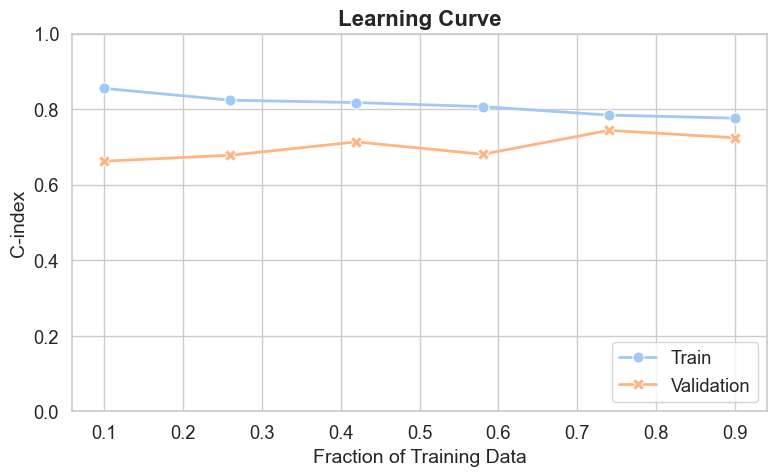

In [13]:
# score looks lower, let's plot curve anyway

# now, let's plot the learning curve to make sure we don't overfit

learning_curve_analysis(pipeline, prepared_data[0], y_surv, PARAMS_XGB)

In [ ]:
# learning curve doesn't overfit but isn't as good as before

Loading Scores...
Done.


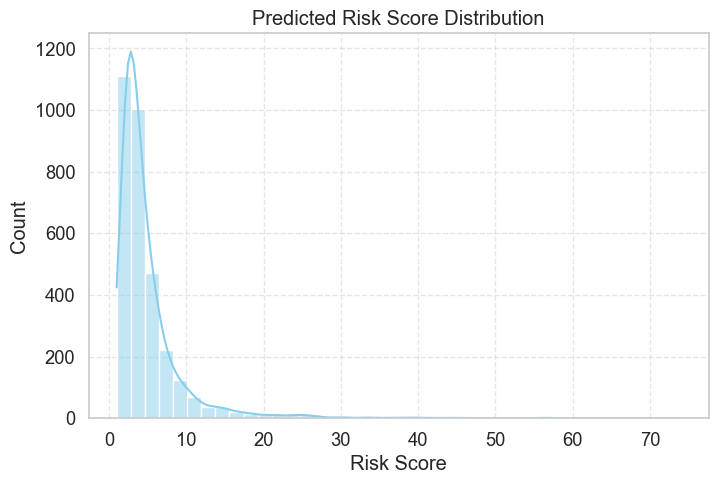

In [14]:
# plot risk scores for patients (first, risk score distribution
best_model=grid_search.best_model
print("Loading Scores...")
plotter = RiskScorePlotter(model=best_model, X=prepared_data[0], y=y_surv)
print("Done.")
plotter.plot_overall_distribution()

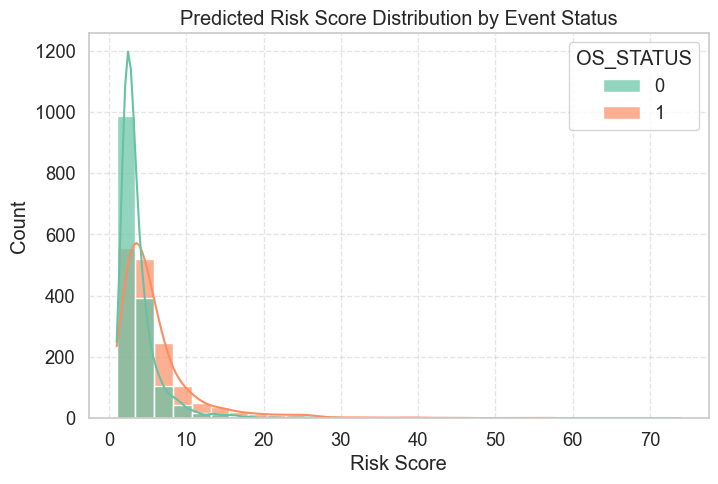

In [15]:
# first distribution of survival prediction per event (0 or 1)
plotter.plot_by_event_status()

In [ ]:
# distribution isn't as differenciated by status, proves again it's not as good as the RSF

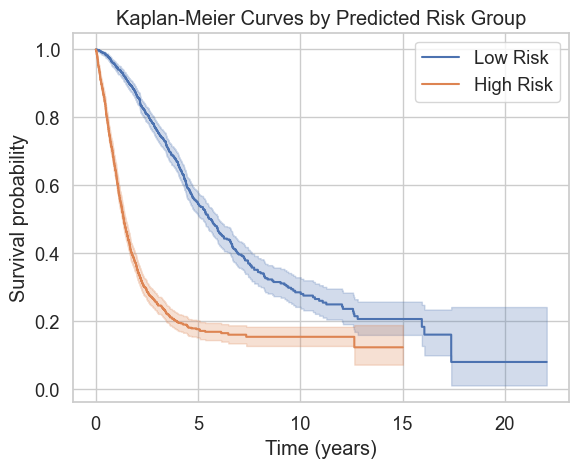

In [16]:
# plot kaplan meyer curve
plotter.plot_kaplan_meier()